# Masked language modeling: predict hidden tokens

Runnable locally on CPU or on a Cloud TPU VM.

- Separate the clean targets from the corrupted input
- Normalize over selected target positions
- Verify the changed-condition exercise and explain the limits of this fixture.

A text model can see a sentence but one word is hidden. What prevents it from copying the answer, and which positions should contribute to its loss? We will train a small bidirectional attention model and audit those two boundaries.

## The idea

Masked language modeling removes selected token information from the model's input and asks it to predict the original tokens. The clean targets remain available to the loss, while the encoder receives only the corrupted sequence.

## Hide the input without hiding the teaching target

Draw a clean sequence splitting into two paths. One supplies labels; the other is corrupted before entering the encoder. Selected-position logits meet the clean labels only at the loss. An arrow from a hidden clean target directly into encoder input would leak the answer.

Bidirectional context means an unmasked token on either side can help prediction. It is separate from the loss-selection mask, which decides which outputs are scored. The current fixture masks selected positions; it is not an implementation of every corruption choice used in BERT.

The loss curve shows learning on the small repeated-token fixture. The probability panel shows which target receives mass at the selected positions. A low fixture loss is separate from robust embeddings or language understanding; changed masks and held-out data test different capabilities.

### Keep clean targets out of encoder inputs

**Predict:** If all visible tokens reveal the same class, what limit does that place on the experiment?

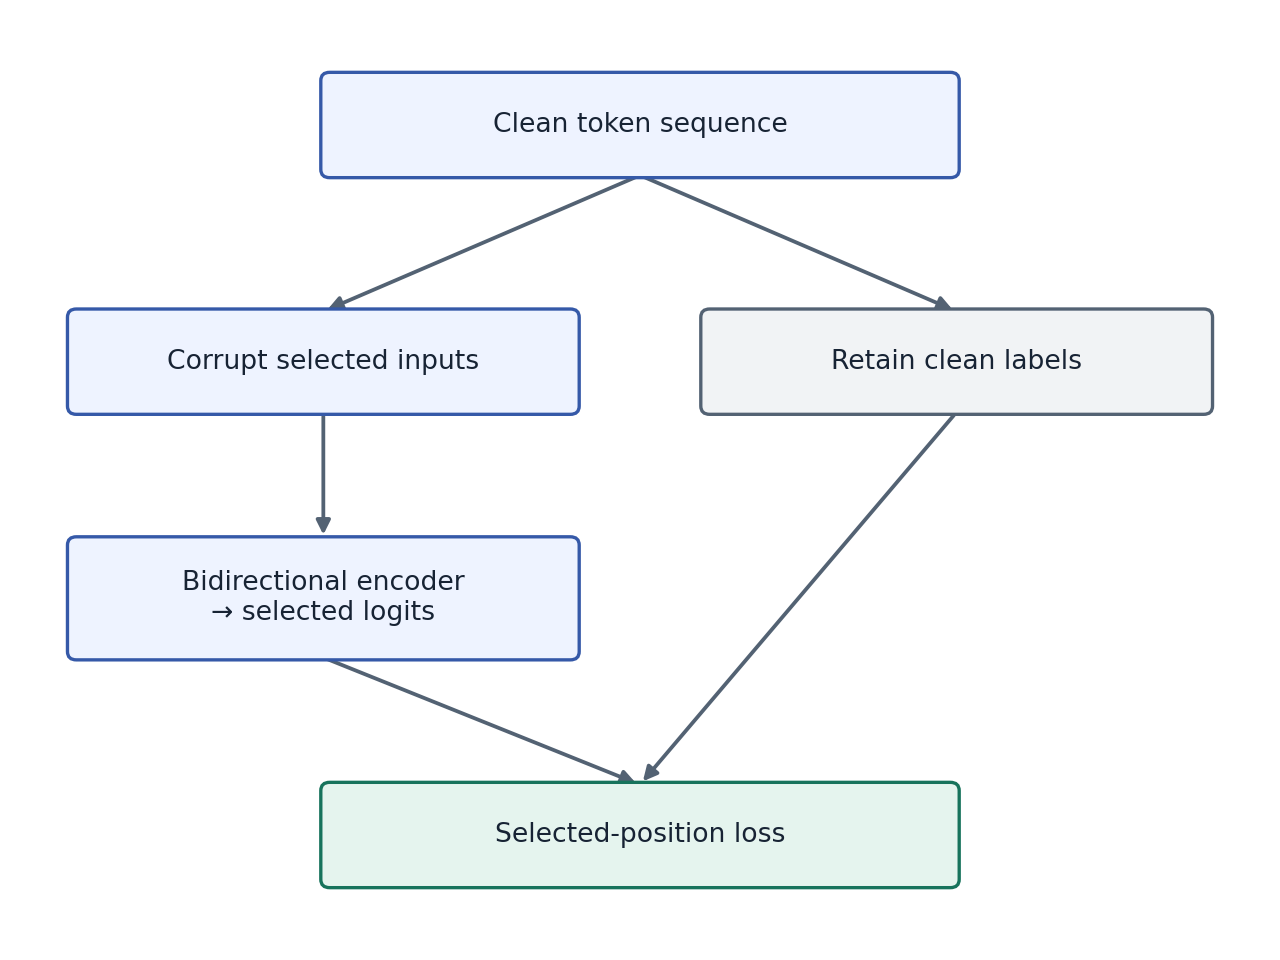

*Architecture and dataflow mechanism diagram.*

Clean tokens fork into labels and a corrupted-input path. Only corrupted inputs enter the encoder. Selected logits meet clean targets at the loss. This makes supervision available without leaking the hidden answer directly into the input.

### Pause and reason

If all visible tokens reveal the same class, what limit does that place on the experiment?

<details><summary>Compare your reasoning</summary>

It makes the objective easy and inspectable, but does not test rich contextual language understanding. Preserve the mechanism check while acknowledging that dataset limitation.

</details>

## Before coding: follow one hidden token

You should be able to turn logits into probabilities and differentiate a scalar loss. Begin with the first clean sequence, $[0,0,0,0]$. Selecting its second position produces input $[0,3,0,0]$, while the target remains $0$. The mask ID $3$ is an input symbol, not a fourth output class. The other visible zeros supply evidence about the missing token. Write down these three objects separately: clean targets, corrupted inputs and the Boolean selection mask. If you cannot say which one enters the encoder, stop before training.

The fixture repeats each token so you can inspect information flow without needing a tokenizer or a large corpus. This simplicity is also its main limitation: a model can solve repetition without learning syntax, word order or meaning.

## Separate the clean targets from the corrupted input

Keep an immutable copy of the original token IDs. The selection mask identifies positions to predict; corruption changes the input tokens, not the targets. Here the extra token ID $3$ means hidden, while output classes are $0,1,2$. Passing clean targets into the encoder would leak the answer. Check the corrupted arrays before the first update.

## Normalize over selected target positions

Compute log-softmax over vocabulary, gather the log probability of each original target, then average only selected positions. For uniform predictions over three classes, the initial loss is $\log 3$, regardless of how many valid positions are selected. Reject an empty mask before entering the jitted step; silently dividing by zero creates an undefined objective.

$$
L=-\frac{\sum_{b,t}m_{bt}\log p_\theta(x_{bt}\mid\widetilde x_b)}{\sum_{b,t}m_{bt}}
$$

## Trace the axes and the gradient

The input IDs have shape $(3,4)$. Looking them up in an embedding table with shape $(4,6)$ produces $(3,4,6)$. Attention scores have shape $(3,4,4)$: the last two axes are query and key positions, not vocabulary classes. The head maps the contextual vectors to logits with shape $(3,4,3)$. Softmax over the final axis now means vocabulary probability. Mixing these two softmax axes gives plausible shapes with the wrong meaning.

Let $M$ be the selected-token count, $p_{btv}$ the vocabulary probability and $x_{bt}$ the original target ID. The derivative below is zero at an unselected output position. It does not say the visible input embeddings have zero gradient: they help predict selected positions through attention.

$$
\frac{\partial L}{\partial z_{btv}}=\frac{m_{bt}}{M}\left(p_{btv}-\mathbf{1}[v=x_{bt}]\right)
$$

## Work out unequal masks before batching

Imagine one sequence contributes one selected token with loss $2$, and another contributes three selected tokens with losses $1,1,1$. The selected-token mean is $(2+3)/4=1.25$. Averaging the two sequence means gives $(2+1)/2=1.5$. Both are well-defined objectives, but they assign different influence to the sequences. Accumulating microbatch losses requires sums and selected counts if you intend to reproduce the token-weighted objective.

Predict which answer appears before running the unequal-mask experiment. Then perturb only unselected target IDs. A correctly reduced objective stays fixed. Next perturb one selected target; the loss should respond unless the competing classes happen to have equal probability.

## Use both sides without using the hidden value

The encoder forms attention scores across every input position. There is no causal triangle: a later visible token is useful evidence here. This tiny model has one attention head, no positional encoding and a linear vocabulary head. Repeated token sequences deliberately avoid word-order ambiguity; a realistic encoder also needs positions, padding handling, residual blocks and a tokenizer.

## Distinguish selection from replacement policy

This lab always replaces selected tokens with the mask ID so information flow is easy to inspect. BERT-style training can mix mask replacement, random replacement and unchanged selected tokens; selection still determines the supervised positions. Keep special/padding tokens ineligible. Track a masking key and regenerate masks under a stated schedule rather than accidentally fixing one easy corruption forever.

## Test a different corruption before claiming progress

The training curve uses one selected position. The code evaluates a second position without additional updates and checks that changing target labels changes the loss. This supports the bounded repeated-token task, not language understanding. A real corpus needs document-separated splits, a frozen tokenizer, mask provenance and downstream evaluation against random initialization.

## Move from this fixture to a corpus deliberately

Keep the objective checker when replacing repeated IDs with tokenized documents. Split by document/source, freeze tokenizer and special-token IDs, exclude padding from selection, and keep an explicit random key for corruption. A full encoder also needs positional information and a tested padding mask. Do not infer these capabilities from this one-head model.

Evaluate a fixed held-out corpus with a documented mask schedule and an aggregate numerator/count. Compare random initialization and a trained checkpoint on the same downstream task. Save one failure case showing a missing dependency, not just an average loss. Moving a mask inside the same three sequences tests corruption transfer; it is not a held-out-language evaluation.

## 1. Define corruption and the selected-token objective

Create main.py in your activated course environment. Paste this block, then run python main.py; function definitions alone print nothing.

In [1]:
# Step 1 — 1. Define corruption and the selected-token objective: The functions separate the input boundary from the differentiable...
# Import jax for this computation.
import jax
import jax.numpy as jnp
import numpy as np

# Function `masked_ce(logits, targets, selected)` implementing this stage's computation:
def masked_ce(logits, targets, selected):
    # Caller validates a nonempty mask before a transformed training step.
    logp = jax.nn.log_softmax(logits, axis=-1)
    # Compute `nll` from `-jnp.take_along_axis(logp, targets[..., None], axis=...`
    nll = -jnp.take_along_axis(logp, targets[..., None], axis=-1)[..., 0]
    # Return `jnp.sum(jnp.where(selected, nll, 0.0)) / jnp.sum(selected)` to the caller.
    return jnp.sum(jnp.where(selected, nll, 0.0)) / jnp.sum(selected)

# Function `validate_mask(selected, shape)` implementing this stage's computation:
def validate_mask(selected, shape):
    # Convert `a` to a host NumPy array for inspection or verification.
    a = np.asarray(selected)
    # Guard input contract (`a.shape != shape or a.dtype != np.bool_ or (not a.any())`) and fail fast if violated.
    if a.shape != shape or a.dtype != np.bool_ or not a.any():
        raise ValueError('a nonempty Boolean mask of the target shape is required')

# Function `corrupt_tokens(tokens, selected, mask_id)` implementing this stage's computation:
def corrupt_tokens(tokens, selected, mask_id):
    # Run `validate_mask` to perform the next check or state transition.
    validate_mask(selected, tokens.shape)
    # Return `jnp.where(selected, mask_id, tokens)` to the caller.
    return jnp.where(selected, mask_id, tokens)

# Function `mlm_logits(p, corrupted)` implementing this stage's computation:
def mlm_logits(p, corrupted):
    # Compute `h` from `p['embedding'][corrupted]`
    h = p['embedding'][corrupted]
    # Bidirectional single-head attention, deliberately no causal mask.
    scores = h @ jnp.swapaxes(h, -1, -2) / jnp.sqrt(h.shape[-1])
    # Perform matrix / vector contraction (`@`) to compute `context`.
    context = jax.nn.softmax(scores, axis=-1) @ h
    # Return `context @ p['head']` to the caller.
    return context @ p['head']

The functions separate the input boundary from the differentiable objective. Read masked_ce from vocabulary normalization to target gather to selected-count reduction.

## 2. Construct a batch whose answers you can inspect

Append this block to main.py and run python main.py again. Keep the earlier blocks above it.

In [2]:
# Step 2 — 2. Construct a batch whose answers you can inspect: Before continuing, inspect corrupted: each row must contain mask...
# Construct `tokens` via `jnp.array([[0, 0, 0, 0], [1, 1, 1, 1], [2, 2, 2, 2]]...`
tokens = jnp.array([[0, 0, 0, 0], [1, 1, 1, 1], [2, 2, 2, 2]], jnp.int32)
# Construct `selected` via `jnp.array([[False, True, False, False]] * 3)`
selected = jnp.array([[False, True, False, False]] * 3)
# Run `corrupt_tokens` to compute `corrupted`.
corrupted = corrupt_tokens(tokens, selected, 3)
# Create or split explicit PRNG key(s) (`key`) for reproducible randomness.
key = jax.random.key(7)
# Sample deterministic random values into `p` using an explicit PRNG key.
p = {
    'embedding': jax.random.normal(key, (4, 6)) * 0.2,
    'head': jnp.zeros((6, 3)),
}
# Compute `loss` from `lambda p: masked_ce(mlm_logits(p, corrupted), tokens...`
loss = lambda p: masked_ce(mlm_logits(p, corrupted), tokens, selected)
# Differentiate the objective to obtain `step` via automatic differentiation.
step = jax.jit(jax.value_and_grad(loss))
# Compute `history` from `[]`
history = []

Before continuing, inspect corrupted: each row must contain mask ID $3$ at the second position. The zero head makes the initial vocabulary distribution uniform.

## 3. Train, then change the corruption

Append this block to main.py and run python main.py again. Keep the earlier blocks above it.

In [3]:
# Step 3 — 3. Train, then change the corruption: The loop measures loss before each update.
for _ in range(100):
    # Run `step` to compute `(value, g)`.
    value, g = step(p)
    # Append the current step result to `history`.
    history.append(float(value))
    # Transform every leaf of the parameter PyTree (`p`).
    p = jax.tree.map(lambda a, b: a - 0.4 * b, p, g)

# Assert invariant `history[-1] < history[0] * 0.15` holds
assert history[-1] < history[0] * 0.15
# Compute `np.testing.assert_allclose(history[0], np.log(3), atol` as `1e-6)`.
np.testing.assert_allclose(history[0], np.log(3), atol=1e-6)
# Changing the clean target after constructing corrupted input cannot change the forward pass.
changed_targets = tokens.at[:, 1].set((tokens[:, 1] + 1) % 3)
# Assert that `not np.isclose(`.
assert not np.isclose(
    float(masked_ce(mlm_logits(p, corrupted), changed_targets, selected)),
    history[-1],
)
# Construct `held_mask` via `jnp.array([[False, False, True, False]] * 3)`
held_mask = jnp.array([[False, False, True, False]] * 3)
# Evaluate `masked_ce(mlm_logits(p, corrupt_tokens(tokens, held_mask, 3)), tokens, held_mask)` and convert the result into Python scalar/collection `held_loss`.
held_loss = float(
    masked_ce(mlm_logits(p, corrupt_tokens(tokens, held_mask, 3)), tokens, held_mask)
)
# Assert invariant `held_loss < 0.2` holds
assert held_loss < 0.2
# Print the observed values to compare against the expected result.
print('MLM initial/final/changed-mask:', history[0], history[-1], held_loss)

MLM initial/final/changed-mask: 1.0986123085021973 0.010633035562932491 0.010457751341164112


The loop measures loss before each update. The final held-mask test uses the updated parameters; do not compare it as if it were the final recorded pre-update point.

## Run the example

In [4]:
# Step 1 — 1. Define corruption and the selected-token objective: The functions separate the input boundary from the differentiable...
# Import jax for this computation.
import jax
import jax.numpy as jnp
import numpy as np

# Function `masked_ce(logits, targets, selected)` implementing this stage's computation:
def masked_ce(logits, targets, selected):
    # Caller validates a nonempty mask before a transformed training step.
    logp = jax.nn.log_softmax(logits, axis=-1)
    # Compute `nll` from `-jnp.take_along_axis(logp, targets[..., None], axis=...`
    nll = -jnp.take_along_axis(logp, targets[..., None], axis=-1)[..., 0]
    # Return `jnp.sum(jnp.where(selected, nll, 0.0)) / jnp.sum(selected)` to the caller.
    return jnp.sum(jnp.where(selected, nll, 0.0)) / jnp.sum(selected)

# Function `validate_mask(selected, shape)` implementing this stage's computation:
def validate_mask(selected, shape):
    # Convert `a` to a host NumPy array for inspection or verification.
    a = np.asarray(selected)
    # Guard input contract (`a.shape != shape or a.dtype != np.bool_ or (not a.any())`) and fail fast if violated.
    if a.shape != shape or a.dtype != np.bool_ or not a.any():
        raise ValueError('a nonempty Boolean mask of the target shape is required')

# Function `corrupt_tokens(tokens, selected, mask_id)` implementing this stage's computation:
def corrupt_tokens(tokens, selected, mask_id):
    # Run `validate_mask` to perform the next check or state transition.
    validate_mask(selected, tokens.shape)
    # Return `jnp.where(selected, mask_id, tokens)` to the caller.
    return jnp.where(selected, mask_id, tokens)

# Function `mlm_logits(p, corrupted)` implementing this stage's computation:
def mlm_logits(p, corrupted):
    # Compute `h` from `p['embedding'][corrupted]`
    h = p['embedding'][corrupted]
    # Bidirectional single-head attention, deliberately no causal mask.
    scores = h @ jnp.swapaxes(h, -1, -2) / jnp.sqrt(h.shape[-1])
    # Perform matrix / vector contraction (`@`) to compute `context`.
    context = jax.nn.softmax(scores, axis=-1) @ h
    # Return `context @ p['head']` to the caller.
    return context @ p['head']

# Step 2 — 2. Construct a batch whose answers you can inspect: Before continuing, inspect corrupted: each row must contain mask...
# Construct `tokens` via `jnp.array([[0, 0, 0, 0], [1, 1, 1, 1], [2, 2, 2, 2]]...`
tokens = jnp.array([[0, 0, 0, 0], [1, 1, 1, 1], [2, 2, 2, 2]], jnp.int32)
# Construct `selected` via `jnp.array([[False, True, False, False]] * 3)`
selected = jnp.array([[False, True, False, False]] * 3)
# Run `corrupt_tokens` to compute `corrupted`.
corrupted = corrupt_tokens(tokens, selected, 3)
# Create or split explicit PRNG key(s) (`key`) for reproducible randomness.
key = jax.random.key(7)
# Sample deterministic random values into `p` using an explicit PRNG key.
p = {
    'embedding': jax.random.normal(key, (4, 6)) * 0.2,
    'head': jnp.zeros((6, 3)),
}
# Compute `loss` from `lambda p: masked_ce(mlm_logits(p, corrupted), tokens...`
loss = lambda p: masked_ce(mlm_logits(p, corrupted), tokens, selected)
# Differentiate the objective to obtain `step` via automatic differentiation.
step = jax.jit(jax.value_and_grad(loss))
# Compute `history` from `[]`
history = []

# Step 3 — 3. Train, then change the corruption: The loop measures loss before each update.
for _ in range(100):
    # Run `step` to compute `(value, g)`.
    value, g = step(p)
    # Append the current step result to `history`.
    history.append(float(value))
    # Transform every leaf of the parameter PyTree (`p`).
    p = jax.tree.map(lambda a, b: a - 0.4 * b, p, g)

# Assert invariant `history[-1] < history[0] * 0.15` holds
assert history[-1] < history[0] * 0.15
# Compute `np.testing.assert_allclose(history[0], np.log(3), atol` as `1e-6)`.
np.testing.assert_allclose(history[0], np.log(3), atol=1e-6)
# Changing the clean target after constructing corrupted input cannot change the forward pass.
changed_targets = tokens.at[:, 1].set((tokens[:, 1] + 1) % 3)
# Assert that `not np.isclose(`.
assert not np.isclose(
    float(masked_ce(mlm_logits(p, corrupted), changed_targets, selected)),
    history[-1],
)
# Construct `held_mask` via `jnp.array([[False, False, True, False]] * 3)`
held_mask = jnp.array([[False, False, True, False]] * 3)
# Evaluate `masked_ce(mlm_logits(p, corrupt_tokens(tokens, held_mask, 3)), tokens, held_mask)` and convert the result into Python scalar/collection `held_loss`.
held_loss = float(
    masked_ce(mlm_logits(p, corrupt_tokens(tokens, held_mask, 3)), tokens, held_mask)
)
# Assert invariant `held_loss < 0.2` holds
assert held_loss < 0.2
# Print the observed values to compare against the expected result.
print('MLM initial/final/changed-mask:', history[0], history[-1], held_loss)

MLM initial/final/changed-mask: 1.0986123085021973 0.010633035562932491 0.010457751341164112


Expected: Loss starts near 1.099 and ends below 0.02; an unseen mask position remains below 0.2.

## Masked language modeling: predict hidden tokens — recorded experiment

Predict: Which cell should dominate each row of final masked-token probabilities, and what would a bright wrong cell tell you?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Compute figure data for: Masked language modeling: predict hidden tokens — recorded experiment
# Compute `visual_data` from `{'kind':'line','xlabel':'completed parameter updates...`
visual_data={'kind':'line','xlabel':'completed parameter updates before measurement','ylabel':'selected-token cross-entropy (nats)','series':[{'label':'recorded CPU training loss','x':list(range(len(history))),'y':history}]}
# Loop over `panel` in `visual_data.get('panels', [visual_data])`:
for panel in visual_data.get('panels',[visual_data]):
    # Compute `panel['x']` from `panel['series'][0]['x']`
    panel['x']=panel['series'][0]['x']

# Convert `final_probabilities` to a host NumPy array for inspection or verification.
final_probabilities=np.asarray(jax.nn.softmax(mlm_logits(p,corrupted)[:,1,:],axis=-1))
# Compute `extra_panel` from `{'kind':'heatmap','values':final_probabilities.tolis...`
extra_panel={'kind':'heatmap','values':final_probabilities.tolist(),'rows':['target 0','target 1','target 2'],'columns':['class 0','class 1','class 2'],'unit':'masked-token probability','xlabel':'predicted vocabulary class','ylabel':'masked example','title':'Final predictions at the selected position'}
# Compute `visual_data` from `{"panels":[*visual_data.get("panels",[visual_data]),...`
visual_data={"panels":[*visual_data.get("panels",[visual_data]),extra_panel]}

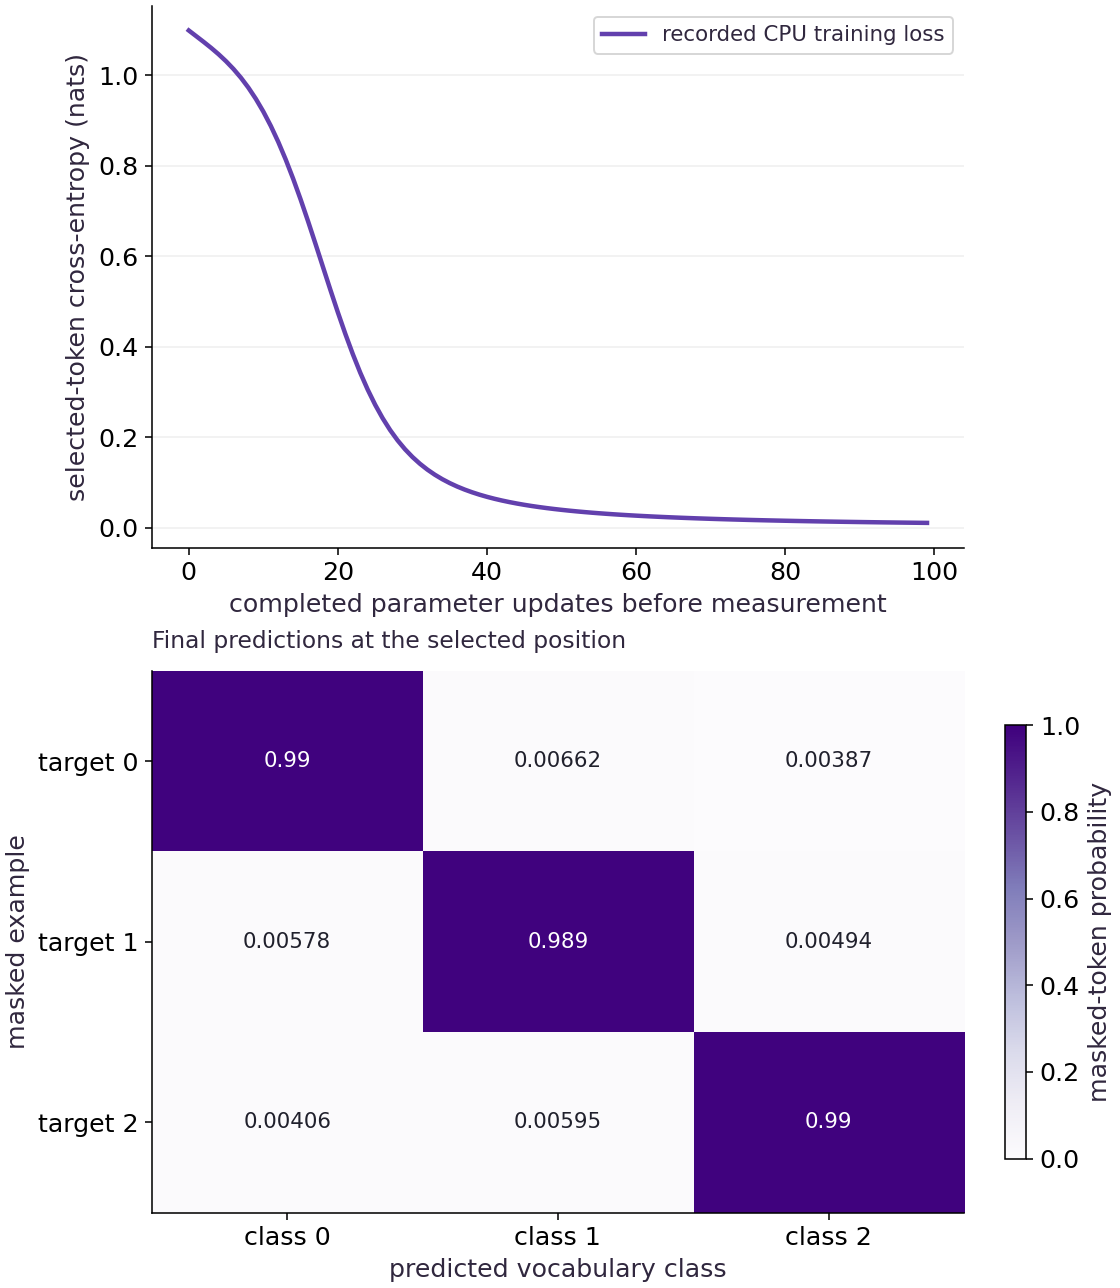

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal axis is the number of updates already applied; the vertical axis is selected-token cross-entropy in nats. The first value is about $1.099=\log 3$. It falls to about $0.011$ on the fixed synthetic sequences. This is training loss, not masked-token accuracy on natural text.

The second panel shows final class probabilities at the hidden position: rows are the three examples and columns are vocabulary classes. Read each row as a distribution that sums to one. The largest cell should lie at that row’s target class. This panel uses the parameters after the last update; the loss curve ends just before that update. Confident diagonal predictions establish this repetition task, not general language understanding.

### Connect it to the computation

The zero vocabulary head makes initial predictions uniform. Falling loss shows the trained attention/embedding/head system can use the remaining repeated tokens. A held mask position is checked separately; the plot does not show a held-out corpus or establish transfer quality.

## Show that unsupervised positions have no direct loss gradient

Predict: If we change logits only where the selection mask is false, does this masked objective change?

In [7]:
# Experiment — Show that unsupervised positions have no direct loss gradient: Visible input tokens can still influence selected predictions...
logits = mlm_logits(p, corrupted)
# Compute `changed_logits` from `jnp.where(`
changed_logits = jnp.where(
    selected[..., None], logits, logits + jnp.array([100.0, -50.0, 7.0])
)
# Execute `np.testing.assert_allclose(`
np.testing.assert_allclose(
    masked_ce(changed_logits, tokens, selected),
    masked_ce(logits, tokens, selected),
    atol=1e-6,
)
# Differentiate the objective to obtain `grad_logits` via automatic differentiation.
grad_logits = jax.grad(masked_ce)(logits, tokens, selected)
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_array_equal(np.asarray(grad_logits)[~np.asarray(selected)], 0.0)
# Print the observed values to compare against the expected result.
print('Unselected output logits have zero direct loss gradient.')

Unselected output logits have zero direct loss gradient.


Expected: Unselected logits do not affect the masked loss and have zero direct gradient.

Visible input tokens can still influence selected predictions through attention. Zero direct gradient at an unselected output is not a claim that visible-token embeddings never learn. The perturbation changes class differences; adding one common scalar to every class would leave softmax unchanged even at supervised positions and would be a weak masking check.

## Use unequal selection counts and a host probability calculation

Predict: Will token-weighted aggregation equal an unweighted average of sequence losses?

In [8]:
# Experiment — Use unequal selection counts and a host probability calculation: The second sequence supplies three of four selected tokens.
# Construct `audit_probs` via `jnp.array([`
audit_probs = jnp.array([
    [[0.8, 0.1, 0.1], [0.2, 0.7, 0.1], [0.2, 0.3, 0.5]],
    [[0.1, 0.6, 0.3], [0.5, 0.2, 0.3], [0.3, 0.4, 0.3]],
])
# Construct `audit_targets` via `jnp.array([[0, 1, 2], [1, 0, 2]])`
audit_targets = jnp.array([[0, 1, 2], [1, 0, 2]])
# Construct `audit_mask` via `jnp.array([[True, False, False], [True, True, True]])`
audit_mask = jnp.array([[True, False, False], [True, True, True]])
# Run `jnp.log` to compute `audit_logits`.
audit_logits = jnp.log(audit_probs)
# Compute `host_losses` from `-np.log(`
host_losses = -np.log(
    np.asarray(audit_probs)[
        np.arange(2)[:, None], np.arange(3)[None, :], np.asarray(audit_targets)
    ]
)
# Aggregate array values to compute `expected`.
expected = host_losses[np.asarray(audit_mask)].mean()
# Evaluate `masked_ce(audit_logits, audit_targets, audit_mask)` and convert the result into Python scalar/collection `observed`.
observed = float(masked_ce(audit_logits, audit_targets, audit_mask))
# Compute `np.testing.assert_allclose(observed, expected, atol` as `1e-6)`.
np.testing.assert_allclose(observed, expected, atol=1e-6)
# Aggregate array values to compute `sequence_mean`.
sequence_mean = np.mean(
    [host_losses[i][np.asarray(audit_mask[i])].mean() for i in range(2)]
)
# Assert that `not np.isclose(observed, sequence_mean)`.
assert not np.isclose(observed, sequence_mean)
# Print diagnostic summary of the computed outputs.
print('Token-weighted / sequence-weighted:', observed, sequence_mean)

Token-weighted / sequence-weighted: 0.6577723026275635 0.51289606


Expected: The independent selected-token mean agrees; the sequence-weighted mean differs.

The second sequence supplies three of four selected tokens. Equal sequence weighting gives the first sequence half of the influence instead of one quarter.

## Your exercise

Select the first position instead of the second and evaluate the trained model without updating it.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.

**Step-by-step implementation plan:**
1. Construct `first_mask` via `jnp.array([[True, False, False, False]] * 3)`
2. Evaluate `masked_ce(mlm_logits(p, corrupt_tokens(tokens, first_mask, 3)), tokens, first_mask)` and convert the result into Python scalar/collection `first_loss`.
3. Assert invariant `first_loss < 0.2` holds
4. Print the observed values to compare against the expected result.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Select the first position instead of the second and evaluate the...
# Construct `first_mask` via `jnp.array([[True, False, False, False]] * 3)`
first_mask = jnp.array(...)  # TODO: compute first_mask
# Evaluate `masked_ce(mlm_logits(p, corrupt_tokens(tokens, first_mask, 3)), tokens, first_mask)` and convert the result into Python scalar/collection `first_loss`.
first_loss = float(...)  # TODO: compute first_loss
    masked_ce(mlm_logits(p, corrupt_tokens(tokens, first_mask, 3)), tokens, first_mask)
)
# Assert invariant `first_loss < 0.2` holds
assert first_loss  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
print('Changed position loss:', first_loss)
```

In [9]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Select the first position instead of the second and evaluate the...
# Construct `first_mask` via `jnp.array([[True, False, False, False]] * 3)`
# first_mask = jnp.array(...)  # TODO: compute first_mask
# Evaluate `masked_ce(mlm_logits(p, corrupt_tokens(tokens, first_mask, 3)), tokens, first_mask)` and convert the result into Python scalar/collection `first_loss`.
# first_loss = float(...)  # TODO: compute first_loss
#     masked_ce(mlm_logits(p, corrupt_tokens(tokens, first_mask, 3)), tokens, first_mask)
# )
# Assert invariant `first_loss < 0.2` holds
# assert first_loss  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
# print('Changed position loss:', first_loss)

## Reference solution

Try your own implementation first.

In [10]:
# Exercise solution: Select the first position instead of the second and evaluate the...
# Construct `first_mask` via `jnp.array([[True, False, False, False]] * 3)`
first_mask = jnp.array([[True, False, False, False]] * 3)
# Evaluate `masked_ce(mlm_logits(p, corrupt_tokens(tokens, first_mask, 3)), tokens, first_mask)` and convert the result into Python scalar/collection `first_loss`.
first_loss = float(
    masked_ce(mlm_logits(p, corrupt_tokens(tokens, first_mask, 3)), tokens, first_mask)
)
# Assert invariant `first_loss < 0.2` holds
assert first_loss < 0.2
# Print the observed values to compare against the expected result.
print('Changed position loss:', first_loss)

Changed position loss: 0.010457751341164112


## Reject a missing learning signal · Transfer

Pass an empty selection mask through the public corruption boundary and require a clear failure.

Hint: Validate outside the transformed objective before dividing by a count.

### How to write: Reject a missing learning signal — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `signal(...)` — Call `signal` with your updated parameters or inputs from this lesson's workspace.
- `corrupt_tokens(...)` — Call `corrupt_tokens` with your updated parameters or inputs from this lesson's workspace.

**Step-by-step implementation plan:**
1. Run the boundary check and catch the expected exception:

**Starter code scaffold (fill in the TODOs):**

```python
# Reject a missing learning signal (Transfer): A skipped batch requires an explicit training policy.
# Run the boundary check and catch the expected exception:
try:
    corrupt_tokens(tokens, jnp.zeros_like(tokens, dtype = ...  # TODO: compute corrupt_tokens(tokens, jnp.zeros_like(tokens, dtype
except ValueError:
    print('Empty mask rejected')
else:
    raise AssertionError('empty mask accepted')
```

In [11]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Reject a missing learning signal (Transfer): A skipped batch requires an explicit training policy.
# Run the boundary check and catch the expected exception:
# try:
#     corrupt_tokens(tokens, jnp.zeros_like(tokens, dtype = ...  # TODO: compute corrupt_tokens(tokens, jnp.zeros_like(tokens, dtype
# except ValueError:
#     print('Empty mask rejected')
# else:
#     raise AssertionError('empty mask accepted')

## Reference reasoning

A skipped batch requires an explicit training policy. It must not silently become a zero loss or a NaN update.

In [12]:
# Reject a missing learning signal (Transfer): A skipped batch requires an explicit training policy.
# Run the boundary check and catch the expected exception:
try:
    corrupt_tokens(tokens, jnp.zeros_like(tokens, dtype=bool), 3)
except ValueError:
    print('Empty mask rejected')
else:
    raise AssertionError('empty mask accepted')

Empty mask rejected


## Derive the output gradient without autodiff · Challenge

Implement the probability-minus-one-hot formula for the unequal-mask fixture and compare every element with autodiff. Explain where visible context can still receive gradient.

Hint: Broadcast the mask over vocabulary and divide by the selected count, not the batch size.

### How to write: Derive the output gradient without autodiff — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `x.sum(axis=...) / x.mean(axis=..., keepdims=...)` — Reduces values along the named `axis` (the axis you name is collapsed unless `keepdims=True`).
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `jax.grad(loss_fn)(params, ...)` — Transforms a scalar-output function into a function returning the gradient PyTree with the same structure as `params`.

**Step-by-step implementation plan:**
1. Reduce along axis=-1 to compute `analytic`.
2. Differentiate the objective to obtain gradients ``.
3. Print the observed values to compare against the expected result.

**Starter code scaffold (fill in the TODOs):**

```python
# Derive the output gradient without autodiff (Challenge): This verifies the entire derivative tensor, including zeros...
# Reduce along axis=-1 to compute `analytic`.
analytic = ...  # TODO: compute analytic
    (jax.nn.softmax(audit_logits, axis=-1) - jax.nn.one_hot(audit_targets, 3))
    * audit_mask[..., None]
    / audit_mask.sum()
)
# Differentiate the objective to obtain gradients ``.
np.testing.assert_allclose(
    jax.grad(masked_ce)(audit_logits, audit_targets, audit_mask),
    analytic,
    atol = ...  # TODO: compute atol
)
# Print the observed values to compare against the expected result.
print('Independent masked softmax gradient agrees.')
```

In [13]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Derive the output gradient without autodiff (Challenge): This verifies the entire derivative tensor, including zeros...
# Reduce along axis=-1 to compute `analytic`.
# analytic = ...  # TODO: compute analytic
#     (jax.nn.softmax(audit_logits, axis=-1) - jax.nn.one_hot(audit_targets, 3))
#     * audit_mask[..., None]
#     / audit_mask.sum()
# )
# Differentiate the objective to obtain gradients ``.
# np.testing.assert_allclose(
#     jax.grad(masked_ce)(audit_logits, audit_targets, audit_mask),
#     analytic,
#     atol = ...  # TODO: compute atol
# )
# Print the observed values to compare against the expected result.
# print('Independent masked softmax gradient agrees.')

## Reference reasoning

This verifies the entire derivative tensor, including zeros at unsupervised outputs. It says nothing by itself about intermediate embedding gradients.

In [14]:
# Derive the output gradient without autodiff (Challenge): This verifies the entire derivative tensor, including zeros...
# Reduce along axis=-1 to compute `analytic`.
analytic = (
    (jax.nn.softmax(audit_logits, axis=-1) - jax.nn.one_hot(audit_targets, 3))
    * audit_mask[..., None]
    / audit_mask.sum()
)
# Differentiate the objective to obtain gradients ``.
np.testing.assert_allclose(
    jax.grad(masked_ce)(audit_logits, audit_targets, audit_mask),
    analytic,
    atol=1e-6,
)
# Print the observed values to compare against the expected result.
print('Independent masked softmax gradient agrees.')

Independent masked softmax gradient agrees.


## Checkpoint

Why are visible input tokens useful even when their output positions are excluded from the loss?

1. They supply context to predictions at selected positions through the encoder.
2. Unselected output logits still receive a nonzero direct cross-entropy gradient.
3. Excluding a position from the loss also masks its key and value vectors out of attention.

## Diagnose

If loss is suspiciously perfect at initialization, inspect target leakage and the selection count. If loss becomes NaN, reject empty masks and inspect vocabulary indices before changing the optimizer.

## Evidence

Keep corrupted inputs, selected-target counts, the log-vocabulary baseline, independent masked-loss checks, trained parameters and changed-mask results.

## Carry forward

- Keep the input-corruption boundary separate from the loss mask: corrupted inputs with shape $(3,4)$ enter the encoder, while clean targets meet vocabulary logits of shape $(3,4,3)$ only inside the selected-token cross-entropy.
- Normalize masked loss by the count of selected tokens $\sum_{b,t} m_{bt}$, reject empty masks before entering a jitted step, and carry numerator and selected-token counts explicitly when accumulating across unequal batches.

## Primary references

- [BERT: masked language pretraining](https://arxiv.org/abs/1810.04805)